In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(23)

In [45]:
print(np.random.randint(1,11,2))
print(np.random.randint(1,11,2))
print(np.random.randint(1,11,2))
print(np.random.randint(1,11,2))

[4 7]
[ 9 10]
[7 9]
[ 8 10]


In [46]:
mu_vec1=np.array([0,0,0])
cov_mat1=np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample=np.random.multivariate_normal(mu_vec1,cov_mat1,20)

df=pd.DataFrame(class1_sample,columns=['x1','x2','x3'])
df['target']=1

mu_vec2=np.array([1,1,1])
cov_mat2=np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample=np.random.multivariate_normal(mu_vec2,cov_mat2,20)

df1=pd.DataFrame(class2_sample,columns=['x1','x2','x3'])
df1['target']=0
df=pd.concat([df, df1], ignore_index=True)
df=df.sample(40)

In [47]:
df.head()

,x1,x2,x3,target
25,1.005268,1.924138,-0.049520,0
2,0.475337,1.522771,-0.473915,1
1,1.207136,1.754727,-0.781682,1
19,-0.708609,-0.657902,-0.297083,1
11,-0.394044,-2.504085,-1.373740,1


In [48]:
import plotly.express as px
fig = px.scatter_3d(df, x='x1', y='x2', z='x3', color=df['target'].astype(str))

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

fig.show()

In [49]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])

In [50]:

# Step 2 - Find Covariance Matrix
covariance_matrix = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print('Covariance Matrix:\n', covariance_matrix)

Covariance Matrix:
 [[1.02564103 0.11650867 0.33551381]
 [0.11650867 1.02564103 0.12944005]
 [0.33551381 0.12944005 1.02564103]]


In [51]:
# Step 3 - Finding EV and EVs
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

In [52]:
eigen_values

array([1.4350507 , 0.68983965, 0.95203273])

In [53]:
eigen_vectors

array([[-0.647393  , -0.7009759 ,  0.29919071],
       [-0.3910611 , -0.03143292, -0.9198278 ],
       [-0.65418156,  0.71249193,  0.25377495]])

In [54]:
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


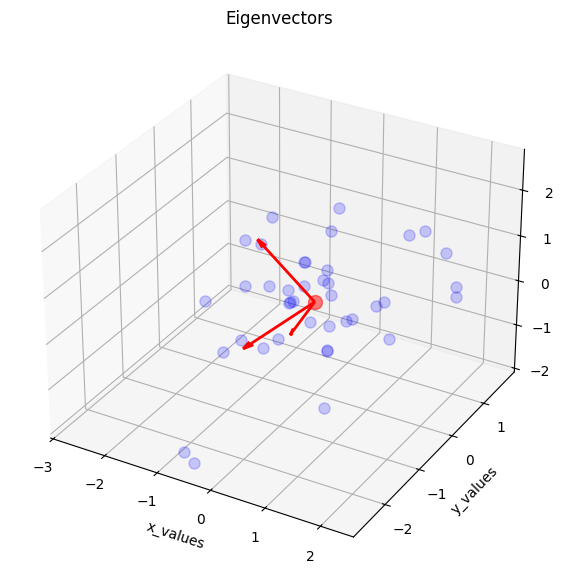

In [55]:
from matplotlib import pyplot as plt
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(df['x1'], df['x2'], df['x3'], 'o', markersize=8, color='blue', alpha=0.2)
ax.plot([df['x1'].mean()], [df['x2'].mean()], [df['x3'].mean()], 'o', markersize=10, color='red', alpha=0.5)
mean = df[['x1', 'x2', 'x3']].mean().to_numpy()
for vector in eigen_vectors.T:
    ax.quiver(*mean, *vector, length=1.5, normalize=True, color='red', linewidth=2, arrow_length_ratio=0.12)
ax.set_xlabel('x_values')
ax.set_ylabel('y_values')
ax.set_zlabel('z_values')

plt.title('Eigenvectors')

plt.show()

In [56]:
pc = eigen_vectors[0:2]
pc

array([[-0.647393  , -0.7009759 ,  0.29919071],
       [-0.3910611 , -0.03143292, -0.9198278 ]])

In [58]:
transformed_df = np.dot(df.iloc[:,0:3],pc.T)
# 40,3 - 3,2
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head()

,PC1,PC2,target
0,-1.310529,0.182426,0
1,-0.865880,0.757447,1
2,-1.543316,0.739555,1
3,1.184195,1.109022,1
4,1.754153,1.963006,1


In [59]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()